In [2]:
import os

raiz = 'Ojos'

# Datos de entrenamiento
train_dir = os.path.join(raiz, 'train')
train_dir_normal = os.path.join(train_dir, 'Normales')
train_dir_glaucoma = os.path.join(train_dir, 'Glaucomas')

# Datos de validación
val_dir = os.path.join(raiz, 'val')
val_dir_normal = os.path.join(val_dir, 'Normales')
val_dir_glaucoma = os.path.join(val_dir, 'Glaucomas')

# Datos de prueba
test_dir = os.path.join(raiz, 'test')
test_dir_normal = os.path.join(test_dir, 'Normales')
test_dir_glaucoma = os.path.join(test_dir, 'Glaucomas')

# Muestro la cantidad de imágenes en cada conjunto
suma_entrenamiento = len(os.listdir(train_dir_normal)) + len(os.listdir(train_dir_glaucoma))
suma_validacion = len(os.listdir(val_dir_normal)) + len(os.listdir(val_dir_glaucoma))
suma_prueba = len(os.listdir(test_dir_normal)) + len(os.listdir(test_dir_glaucoma))

print("Datos de entrenamiento:", suma_entrenamiento, "--- Normales:", len(os.listdir(train_dir_normal)), "--- Glaucoma:", len(os.listdir(train_dir_glaucoma)))
print("Datos de validación:", suma_validacion, "--- Normales:", len(os.listdir(val_dir_normal)), "--- Glaucoma:", len(os.listdir(val_dir_glaucoma)))
print("Datos de prueba:", suma_prueba, "--- Normales:", len(os.listdir(test_dir_normal)), "--- Glaucoma:", len(os.listdir(test_dir_glaucoma)))

Datos de entrenamiento: 339 --- Normales: 219 --- Glaucoma: 120
Datos de validación: 48 --- Normales: 31 --- Glaucoma: 17
Datos de prueba: 98 --- Normales: 63 --- Glaucoma: 35


In [6]:
# Realizo el data augmentation para mi conjunto de entrenamiento, validación y prueba
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

train_generator = ImageDataGenerator(preprocessing_function=preprocess_input,
                                     rotation_range=5,      # Rota la imagen hasta 20 grados
                                     width_shift_range=0.02,  # Mueve la imagen a los lados
                                     height_shift_range=0.02, # Mueve la imagen arriba/abajo
                                     zoom_range=0.2,         # Aplica un 20% de zoom aleatorio
                                     horizontal_flip=True,    # Efecto espejo
)

val_generator = ImageDataGenerator(preprocessing_function=preprocess_input
)

test_generator = ImageDataGenerator(preprocessing_function=preprocess_input)

In [8]:
# Muestro el antes y después del data augmentation
import matplotlib.pyplot as plt
import numpy as np
# Función para mostrar imágenes
def mostrar_imagenes(generator, dir_normal, dir_glaucoma):
    # Tomo una imagen de cada clase
    img_normal = plt.imread(os.path.join(dir_normal, os.listdir(dir_normal)[0]))
    img_glaucoma = plt.imread(os.path.join(dir_glaucoma, os.listdir(dir_glaucoma)[0]))

    # Aplico el data augmentation a ambas imágenes
    img_normal_aug = generator.random_transform(img_normal)
    img_glaucoma_aug = generator.random_transform(img_glaucoma)

    # Muestro las imágenes originales y aumentadas
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    axes[0, 0].imshow(img_normal)
    axes[0, 0].set_title('Normal Original')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(img_normal_aug)
    axes[0, 1].set_title('Normal Aumentada')
    axes[0, 1].axis('off')

    axes[1, 0].imshow(img_glaucoma)
    axes[1, 0].set_title('Glaucoma Original')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(img_glaucoma_aug)
    axes[1, 1].set_title('Glaucoma Aumentada')
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

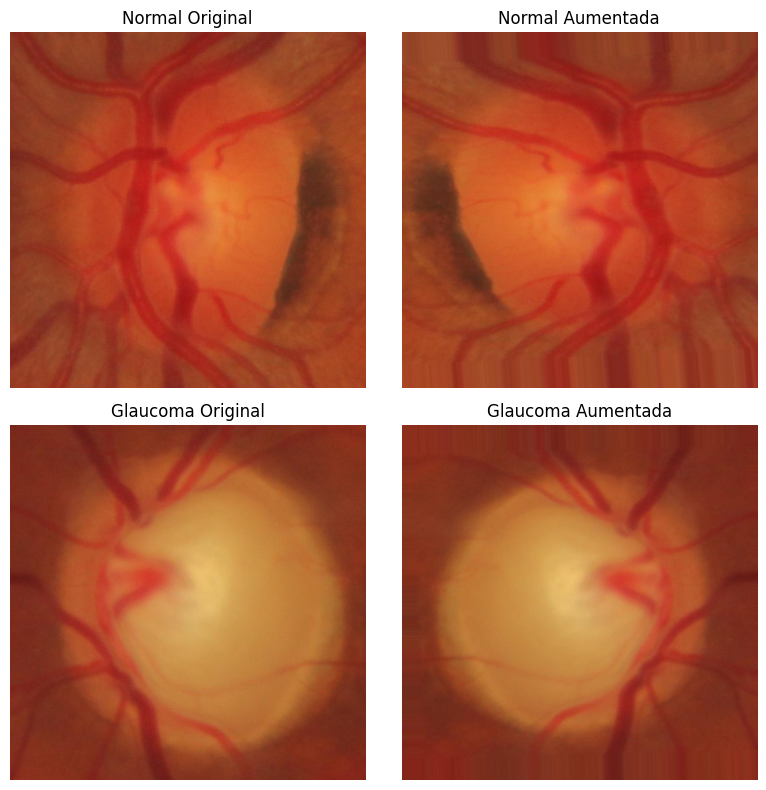

In [4]:
# Muestro la imágen
mostrar_imagenes(train_generator, train_dir_normal, train_dir_glaucoma)

In [9]:
train_generator = train_generator.flow_from_directory(train_dir,
                                    target_size=(224, 224),
                                    class_mode='categorical',
                                    classes=['Normales', 'Glaucomas'],
                                    batch_size=16)

val_generator = val_generator.flow_from_directory(val_dir,
                                  target_size=(224, 224),
                                  class_mode='categorical',
                                  classes=['Normales', 'Glaucomas'],
                                  batch_size=16)

test_generator = test_generator.flow_from_directory(test_dir,
                                   target_size=(224, 224),
                                   class_mode='categorical',
                                   classes=['Normales', 'Glaucomas'],
                                   batch_size=16)

Found 339 images belonging to 2 classes.
Found 48 images belonging to 2 classes.


Found 98 images belonging to 2 classes.


In [14]:
# Obtención del modelo VGG16 preentrenado sin la parte de clasificación (sin las capas densas finales)
from tensorflow.keras.applications import resnet50

base_model = resnet50.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layers in base_model.layers:
    layers.trainable = False

base_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [15]:
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras import Sequential

model = Sequential()
model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.3))
model.add(Dense(2, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [18]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

name_model = 'models/glaucomaResnet50.h5'

checkpoint = ModelCheckpoint(name_model,
                             monitor='val_accuracy',
                             save_best_only=True,
                             mode='max',
                             verbose=1)

model.fit(train_generator,
          epochs=100,
          validation_data=val_generator,
          callbacks=[checkpoint])

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - accuracy: 0.6287 - loss: 0.9642
Epoch 1: val_accuracy improved from None to 0.64583, saving model to models/glaucomaResnet50.h5


22/22 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.6342 - loss: 0.9622 - val_accuracy: 0.6458 - val_loss: 0.8110
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 682ms/step - accuracy: 0.5962 - loss: 0.9447
Epoch 2: val_accuracy did not improve from 0.64583
22/22 ━━━━━━━━━━━━━━━━━━━━ 17s 787ms/step - accuracy: 0.6136 - loss: 0.8953 - val_accuracy: 0.6458 - val_loss: 0.7589
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 826ms/step - accuracy: 0.6781 - loss: 0.8194
Epoch 3: val_accuracy did not improve from 0.64583
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 947ms/step - accuracy: 0.6401 - loss: 0.8748 - val_accuracy: 0.6458 - val_loss: 0.7231
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.5976 - loss: 0.8792
Epoch 4: val_accuracy did not improve from 0.64583
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 741ms/step - accuracy: 0.6047 - loss: 0.8651 - val_accuracy: 0.6458 - val_loss: 0.6936
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.6085 - loss: 0.8395
Epoch 5: val_accuracy did not 

22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 738ms/step - accuracy: 0.6224 - loss: 0.7583 - val_accuracy: 0.6667 - val_loss: 0.6232
Epoch 14/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.6088 - loss: 0.7562
Epoch 14: val_accuracy did not improve from 0.66667
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 719ms/step - accuracy: 0.5900 - loss: 0.7988 - val_accuracy: 0.6667 - val_loss: 0.6222
Epoch 15/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.6411 - loss: 0.6917
Epoch 15: val_accuracy did not improve from 0.66667
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 739ms/step - accuracy: 0.6372 - loss: 0.6923 - val_accuracy: 0.6667 - val_loss: 0.6186
Epoch 16/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.6297 - loss: 0.7375
Epoch 16: val_accuracy did not improve from 0.66667
22/22 ━━━━━━━━━━━━━━━━━━━━ 17s 755ms/step - accuracy: 0.6165 - loss: 0.7776 - val_accuracy: 0.6458 - val_loss: 0.6152
Epoch 17/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.6272 - loss: 0.7499
Epoch 17: val_accura

In [19]:
model.load_weights(name_model)

test_loss, test_acc = model.evaluate(test_generator)
print("test_acc:", test_acc)
print("test_loss:", test_loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 565ms/step - accuracy: 0.6429 - loss: 0.6301
test_acc: 0.6428571343421936
test_loss: 0.6300541162490845


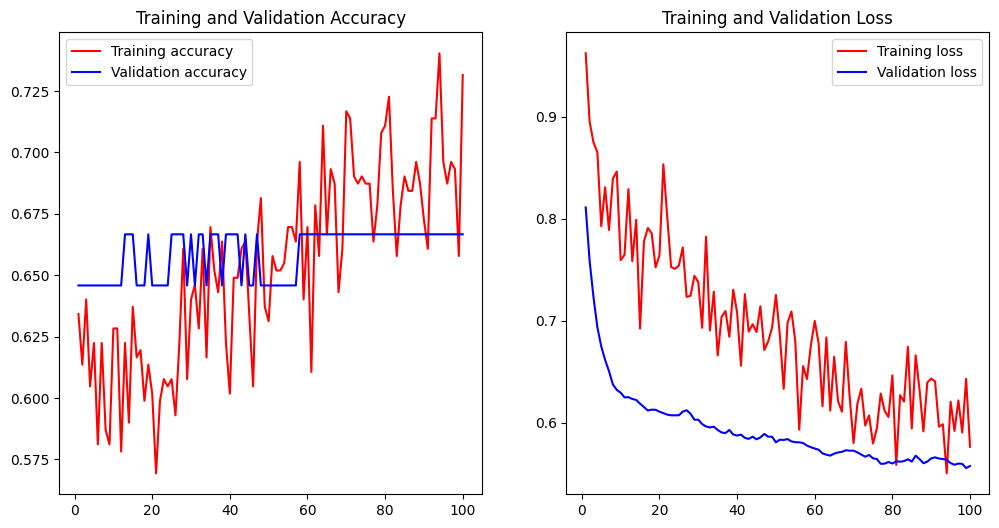

In [20]:
# Pinto las curvas de entrenamiento y validación

# Muestro las gráficas de entrenamiento
import matplotlib.pyplot as plt

# Gráficos de entrenamiento
acc = model.history.history['accuracy']
val_acc = model.history.history['val_accuracy']
loss = model.history.history['loss']
val_loss = model.history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

In [21]:
from tensorflow.keras.optimizers import Adam

model.load_weights('models/glaucomaResnet50.h5')

model.trainable = True # Descongelo todas las capas para el deep-tuning

name_deep = 'models/glaucomaResnet50_deep.h5'

checkpointDeep = ModelCheckpoint(name_deep,
                                 monitor='val_accuracy',
                                 save_best_only=True,
                                 mode='max',
                                 verbose=1)

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_generator,
          epochs=100,
          validation_data=val_generator,
          callbacks=[checkpointDeep])

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 646ms/step - accuracy: 0.6414 - loss: 0.7554
Epoch 1: val_accuracy improved from None to 0.66667, saving model to models/glaucomaResnet50_deep.h5


22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 857ms/step - accuracy: 0.6283 - loss: 0.7585 - val_accuracy: 0.6667 - val_loss: 0.6184
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.6604 - loss: 0.7222
Epoch 2: val_accuracy did not improve from 0.66667
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 731ms/step - accuracy: 0.6372 - loss: 0.7234 - val_accuracy: 0.6458 - val_loss: 0.6135
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.6091 - loss: 0.7450
Epoch 3: val_accuracy did not improve from 0.66667
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 729ms/step - accuracy: 0.6047 - loss: 0.7391 - val_accuracy: 0.6667 - val_loss: 0.6102
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.6276 - loss: 0.7321
Epoch 4: val_accuracy did not improve from 0.66667
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 742ms/step - accuracy: 0.6047 - loss: 0.7454 - val_accuracy: 0.6667 - val_loss: 0.6085
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 646ms/step - accuracy: 0.6296 - loss: 0.7311
Epoch 5: val_accuracy did n

22/22 ━━━━━━━━━━━━━━━━━━━━ 17s 778ms/step - accuracy: 0.6696 - loss: 0.6593 - val_accuracy: 0.6875 - val_loss: 0.5808
Epoch 53/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - accuracy: 0.6249 - loss: 0.6705
Epoch 53: val_accuracy did not improve from 0.68750
22/22 ━━━━━━━━━━━━━━━━━━━━ 17s 755ms/step - accuracy: 0.6490 - loss: 0.6722 - val_accuracy: 0.6667 - val_loss: 0.5784
Epoch 54/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - accuracy: 0.6494 - loss: 0.6605
Epoch 54: val_accuracy did not improve from 0.68750
22/22 ━━━━━━━━━━━━━━━━━━━━ 17s 765ms/step - accuracy: 0.6726 - loss: 0.6390 - val_accuracy: 0.6667 - val_loss: 0.5758
Epoch 55/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.6742 - loss: 0.6348
Epoch 55: val_accuracy did not improve from 0.68750
22/22 ━━━━━━━━━━━━━━━━━━━━ 17s 756ms/step - accuracy: 0.6667 - loss: 0.6650 - val_accuracy: 0.6667 - val_loss: 0.5715
Epoch 56/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.6937 - loss: 0.6114
Epoch 56: val_accura

In [22]:
model.load_weights(name_deep)

test_loss, test_acc = model.evaluate(test_generator)
print("test_acc:", test_acc)
print("test_loss:", test_loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 545ms/step - accuracy: 0.6939 - loss: 0.5306
test_acc: 0.6938775777816772
test_loss: 0.5305991172790527


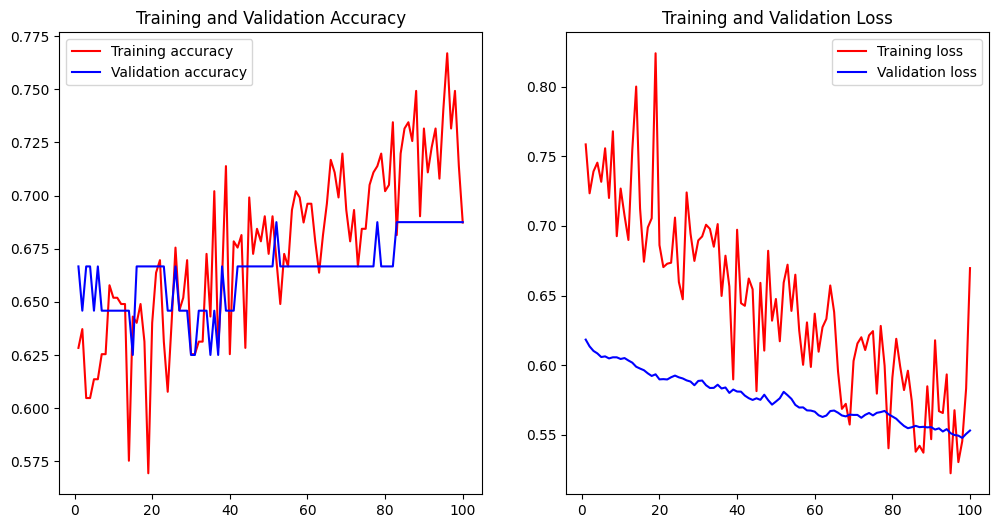

In [23]:
# Gráficos de entrenamiento
acc = model.history.history['accuracy']
val_acc = model.history.history['val_accuracy']
loss = model.history.history['loss']
val_loss = model.history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()